Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/Dataset-NetworkScience/Dataset-NetworkScience

  DATASET: karate
  Nodes : 34
  Edges : 78
  T     : 3

  Top 5 Nodes by Diffusion Centrality
  ------------------------------------------
  Rank  Node                Score
  ------------------------------------------
  1     34                  6.114
  2     1                   5.883
  3     33                  4.802
  4     3                   4.527
  5     2                   3.852
  ------------------------------------------


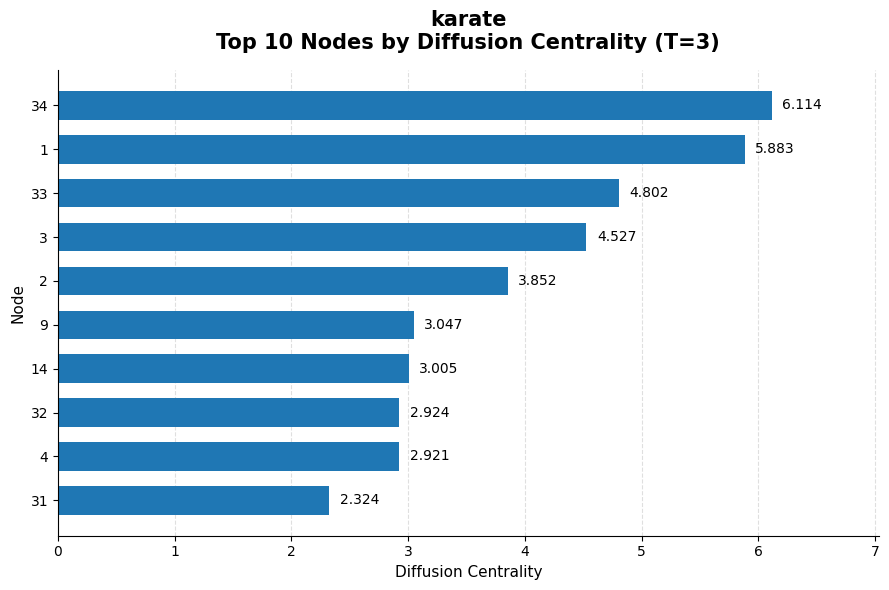


  ✓ Chart saved: figures_simple/karate_top10.png

  DATASET: dolphins
  Nodes : 62
  Edges : 159
  T     : 3

  Top 5 Nodes by Diffusion Centrality
  ------------------------------------------
  Rank  Node                Score
  ------------------------------------------
  1     15                  4.955
  2     38                  4.722
  3     46                  4.570
  4     34                  4.264
  5     52                  3.583
  ------------------------------------------


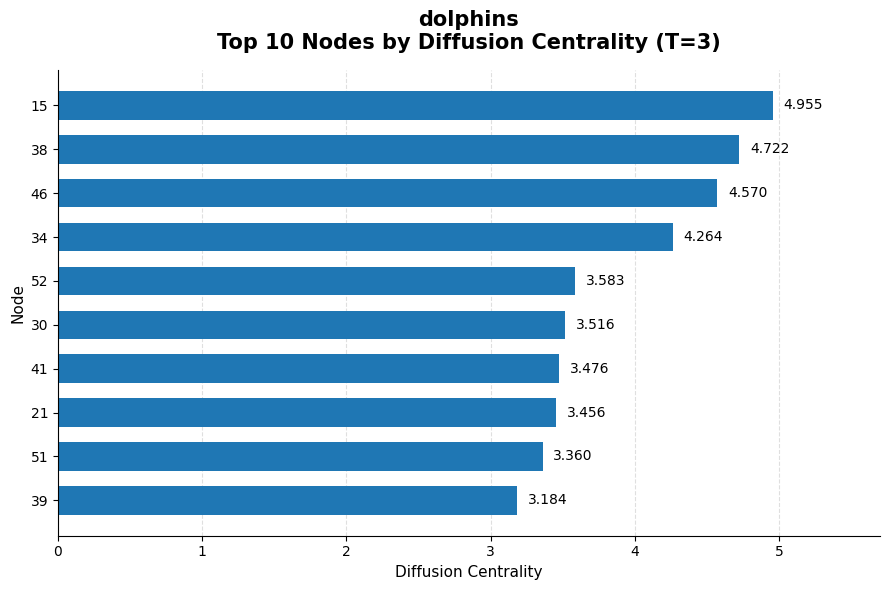


  ✓ Chart saved: figures_simple/dolphins_top10.png

  DATASET: football
  Nodes : 115
  Edges : 613
  T     : 3

  Top 5 Nodes by Diffusion Centrality
  ------------------------------------------
  Rank  Node                Score
  ------------------------------------------
  1     67                  3.460
  2     2                   3.438
  3     53                  3.436
  4     15                  3.413
  5     88                  3.409
  ------------------------------------------


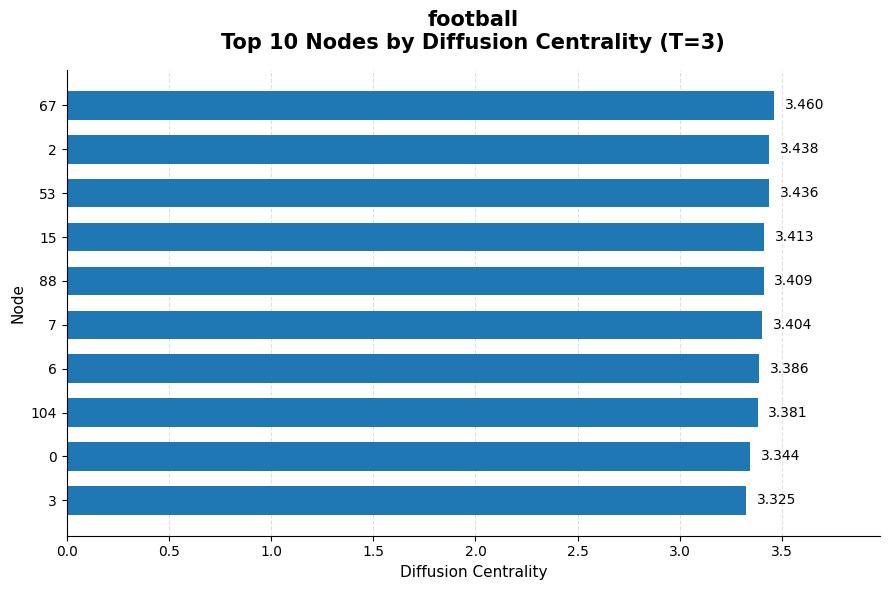


  ✓ Chart saved: figures_simple/football_top10.png

  DATASET: polbooks
  Nodes : 105
  Edges : 441
  T     : 3

  Top 5 Nodes by Diffusion Centrality
  ------------------------------------------
  Rank  Node                Score
  ------------------------------------------
  1     9                   5.875
  2     13                  5.769
  3     85                  5.509
  4     74                  5.205
  5     4                   5.140
  ------------------------------------------


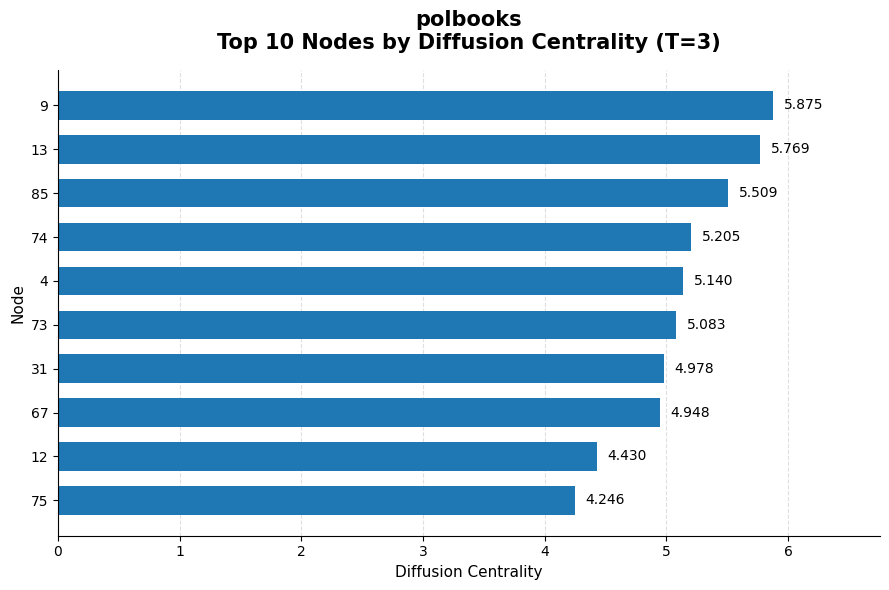


  ✓ Chart saved: figures_simple/polbooks_top10.png

  DATASET: reachability
  Nodes : 456
  Edges : 71959
  T     : 3

  Top 5 Nodes by Diffusion Centrality
  ------------------------------------------
  Rank  Node                Score
  ------------------------------------------
  1     176                 8.371
  2     14                  6.699
  3     219                 6.482
  4     200                 6.351
  5     136                 5.920
  ------------------------------------------


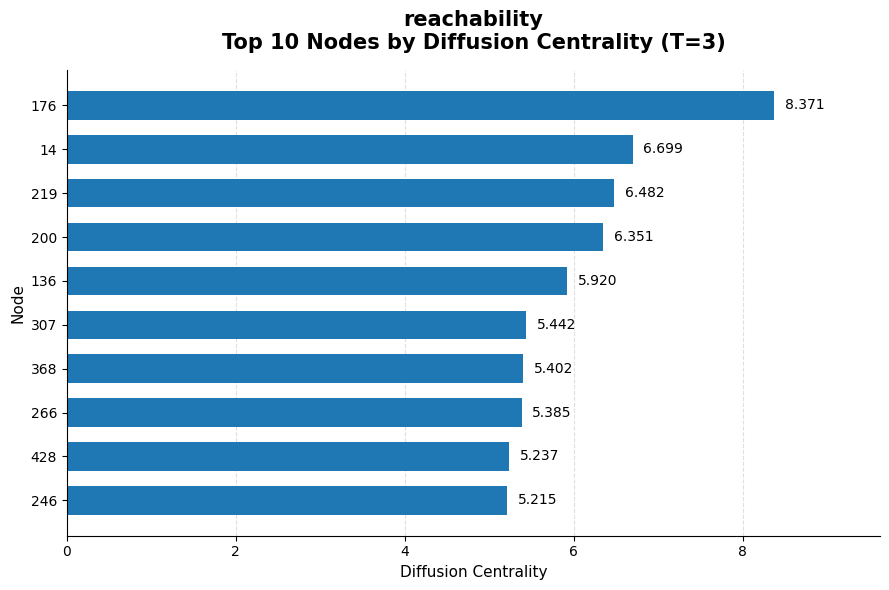


  ✓ Chart saved: figures_simple/reachability_top10.png


In [3]:
"""
diffusion_centrality_simple.py
==============================

Compute Diffusion Centrality for each dataset,
print the top 5 nodes, and save a Top-10 bar chart.

Formula:
DC = [sum from l=1 to T of (qA)^l] * 1
"""


# ================================================================
# MOUNT GOOGLE DRIVE
# ================================================================

from google.colab import drive

drive.mount('/content/drive')


# Copy project from Google Drive to Colab
!cp -r /content/drive/MyDrive/Dataset-NetworkScience .

# Move into the project folder
%cd Dataset-NetworkScience


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Used to calculate the largest eigenvalue
from scipy.sparse.linalg import eigsh


# ================================================================
# 2. INPUT AND OUTPUT DIRECTORIES
# ================================================================

# Dataset files are in the current folder
DATA_DIR = ""

# Folder for generated charts
OUT_DIR = "figures_simple"

# Create output folder
os.makedirs(
    OUT_DIR,
    exist_ok=True
)


# ================================================================
# 3. DIFFUSION CENTRALITY
# ================================================================

def diffusion_centrality(
    G,
    node=None,
    q=None,
    T=3,
    normalized=False
):

    # Convert graph to adjacency matrix
    A = nx.to_numpy_array(G)

    n = A.shape[0]


    # Make negative weights positive
    if (A < 0).any():
        A = np.abs(A)


    # Calculate q if not given
    if q is None:

        # Check whether graph is symmetric
        symmetric = np.allclose(
            A,
            A.T
        )


        # Faster method for large symmetric graphs
        if n > 100 and symmetric:

            lam1 = eigsh(
                A,
                k=1,
                which="LM",
                return_eigenvectors=False
            )[0]


        # Direct eigenvalue calculation
        else:

            lam1 = np.max(
                np.abs(
                    np.linalg.eigvals(A)
                )
            )


        # q = 1 / largest eigenvalue
        q = (
            1.0 / lam1
            if lam1 > 0
            else 0.0
        )


    # Calculate powers of qA
    qA = q * A

    power = np.eye(n)

    result = np.zeros(n)


    # Add (qA)^1 + ... + (qA)^T
    for _ in range(T):

        power = power @ qA

        result += (
            power @ np.ones(n)
        )


    # Normalize scores if requested
    if normalized and result.max() > 0:

        result = (
            result / result.max()
        )


    # Return one node's score
    if node is not None:

        return result[
            list(G.nodes()).index(node)
        ]


    # Return scores for all nodes
    return dict(
        zip(
            G.nodes(),
            result
        )
    )


# ================================================================
# 4. DATASETS
# ================================================================

DATASETS = {

    "karate": {
        "file": "karate.edgelist",
        "weighted": False,
        "directed": False
    },

    "dolphins": {
        "file": "dolphins.edgelist",
        "weighted": False,
        "directed": False
    },

    "football": {
        "file": "football.edgelist",
        "weighted": False,
        "directed": False
    },

    "polbooks": {
        "file": "polbooks.edgelist",
        "weighted": False,
        "directed": False
    },

    "reachability": {
        "file": "reachability.edgelist",
        "weighted": True,
        "directed": True
    }
}


# ================================================================
# 5. LOAD DATASET
# ================================================================

def load_graph(
    name,
    spec
):

    # Create file path
    path = os.path.join(
        DATA_DIR,
        spec["file"]
    )


    # Check whether file exists
    if not os.path.exists(path):

        print(
            f"[skip] {name}: file not found ({path}). "
            f"Run download_datasets.py first."
        )

        return None


    # Select directed or undirected graph
    create_using = (
        nx.DiGraph
        if spec["directed"]
        else nx.Graph
    )


    # Load weighted graph
    if spec["weighted"]:

        return nx.read_weighted_edgelist(
            path,
            create_using=create_using
        )


    # Load normal graph
    return nx.read_edgelist(
        path,
        create_using=create_using
    )


# ================================================================
# 6. MAIN PROGRAM
# ================================================================

def main():

    # Process every dataset
    for name, spec in DATASETS.items():


        # --------------------------------------------------------
        # Load graph
        # --------------------------------------------------------

        G = load_graph(
            name,
            spec
        )


        # Skip if graph is not available
        if G is None:
            continue


        # Get graph size
        n = G.number_of_nodes()
        m = G.number_of_edges()


        # --------------------------------------------------------
        # Dataset Information
        # --------------------------------------------------------

        print(
            "\n" + "=" * 60
        )

        print(
            f"  DATASET: {name}"
        )

        print(
            "=" * 60
        )

        print(
            f"  Nodes : {n}"
        )

        print(
            f"  Edges : {m}"
        )

        print(
            f"  T     : 3"
        )


        # --------------------------------------------------------
        # Calculate Diffusion Centrality
        # --------------------------------------------------------

        dc = diffusion_centrality(
            G,
            T=3
        )


        # --------------------------------------------------------
        # Rank Nodes
        # --------------------------------------------------------

        ranked = sorted(
            dc.items(),
            key=lambda kv: kv[1],
            reverse=True
        )


        # --------------------------------------------------------
        # Print Top 5 Nodes
        # --------------------------------------------------------

        print(
            "\n  Top 5 Nodes by Diffusion Centrality"
        )

        print(
            "  " + "-" * 42
        )

        print(
            f"  {'Rank':<6}"
            f"{'Node':<15}"
            f"{'Score':>10}"
        )

        print(
            "  " + "-" * 42
        )


        for rank, (node, score) in enumerate(
            ranked[:5],
            start=1
        ):

            print(
                f"  {rank:<6}"
                f"{str(node):<15}"
                f"{score:>10.3f}"
            )


        print(
            "  " + "-" * 42
        )


        # --------------------------------------------------------
        # Select Top 10 Nodes
        # --------------------------------------------------------

        top10 = ranked[:10]


        labels = [
            str(node)
            for node, _ in top10
        ]


        values = [
            score
            for _, score in top10
        ]


        # Reverse for horizontal bar chart
        labels = labels[::-1]
        values = values[::-1]


        # --------------------------------------------------------
        # Create Bar Chart
        # --------------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(9, 6)
        )


        bars = ax.barh(
            labels,
            values,
            height=0.65
        )


        # --------------------------------------------------------
        # Add Scores
        # --------------------------------------------------------

        max_value = max(values)


        for bar, value in zip(
            bars,
            values
        ):

            ax.text(
                value + max_value * 0.015,
                bar.get_y()
                + bar.get_height() / 2,
                f"{value:.3f}",
                va="center",
                fontsize=10
            )


        # --------------------------------------------------------
        # Chart Formatting
        # --------------------------------------------------------

        ax.set_title(
            f"{name}\n"
            f"Top 10 Nodes by Diffusion Centrality (T=3)",
            fontsize=15,
            fontweight="bold",
            pad=15
        )


        ax.set_xlabel(
            "Diffusion Centrality",
            fontsize=11
        )


        ax.set_ylabel(
            "Node",
            fontsize=11
        )


        # Remove unnecessary borders
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


        # Add vertical grid
        ax.grid(
            axis="x",
            linestyle="--",
            alpha=0.4
        )


        ax.set_axisbelow(True)


        # Leave space for score labels
        ax.set_xlim(
            0,
            max_value * 1.15
        )


        plt.tight_layout()


        # --------------------------------------------------------
        # Save Chart
        # --------------------------------------------------------

        out_path = os.path.join(
            OUT_DIR,
            f"{name}_top10.png"
        )


        plt.savefig(
            out_path,
            dpi=200,
            bbox_inches="tight"
        )


        # Display chart
        plt.show()


        # Close figure
        plt.close()


        # --------------------------------------------------------
        # Completion Message
        # --------------------------------------------------------

        print(
            f"\n  ✓ Chart saved: {out_path}"
        )

        print(
            "=" * 60
        )


# ================================================================
# 7. START PROGRAM
# ================================================================

if __name__ == "__main__":

    main()